In [281]:
# =========================================
# 📚 IMPORT ALL REQUIRED LIBRARIES (TOP CELL)
# =========================================

# Data handling
import pandas as pd
import numpy as np

# Text processing
import re

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Models 
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, classification_report
# Save model
import joblib
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import random
from sklearn.model_selection import learning_curve



In [282]:
#LOAD DATASET

In [283]:
# Load
data = pd.read_csv(
    "../datasets/tigrigna_translated_news_dataset(5).csv",
    encoding="utf-8-sig",   # 👈 IMPORTANT FIX
    sep=None,
    engine="python"
)

# Clean column names
data.columns = data.columns.str.strip()

# Inspect
print("Columns:", list(data.columns))

# Rename properly (adjust based on output)
data.columns = data.columns.str.replace('\ufeff', '', regex=True).str.strip()

data.rename(columns=lambda x: x.strip().lower(), inplace=True)

data.rename(columns={
    'tigrigna_translated_text': 'text',
    'label': 'label'
}, inplace=True)

print(data.columns)
print(data[['text']].head())

Columns: ['Tigrigna_translated_text', 'label']
Index(['text', 'label'], dtype='str')
                                                text
0  ላዕለዋይ ቤት ፍርዲ ማሳቹሰትስ ብዛዕባ ማእሰርቲ ስደተኛታት ዝሃቦ ውሳነ ...
1  ኣመሪካ ብሰንኪ እቲ ኣብ ልዕሊ ዘይመንግስታውያን ትካላት ዝተወሰነ ቀይዲ፡...
2  ረክስ ቲለርሰን ካብ ስልጣኖም ከምዘይለቁን ምስ ትራምፕ ጽቡቕ ርክብ ከምዘ...
3  ኣባላት ኮንግረስ ኣመሪካ ኣብ ልዕሊ ሩስያ ሓድሽ እገዳ ንምንባር ተሰማሚዖ...
4  ዶናልድ ትራምፕ ንገዛኢ ክፍለ-ሃገር ካንሳስ ሳም ብራውንባክ ኣምባሳደር ኣ...


In [284]:
# ===============================
# 🧹 TEXT CLEANING FUNCTION
# ===============================

def clean_text(text):
    text = str(text)
    
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    
    # Remove Tigrigna punctuation explicitly
    text = re.sub(r'[፡።፣፤፥፦]', '', text)
    
    # Remove English punctuation
    text = re.sub(r'[^\w\sሀ-፿]', '', text)
    
    # Normalize spaces
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()
    

data['clean_text'] = data['text'].apply(clean_text)

In [285]:
# ===============================
# 🧹 CLEAN LABELS (STRONG VERSION)
# ===============================

# Remove missing values early
data = data.dropna(subset=['text', 'label'])

# Convert label to numeric
data['label'] = pd.to_numeric(data['label'], errors='coerce')

# Drop invalid rows again
data = data.dropna(subset=['label'])

# Convert to int
data['label'] = data['label'].astype(int)

# Define X and y AFTER cleaning
X = data['text']
y = data['label']

print("Remaining NaN:", data['label'].isnull().sum())
print("Label values:", data['label'].unique())

Remaining NaN: 0
Label values: [1 0]


In [286]:
# ===============================
# 🔄 NORMALIZATION FUNCTION
# ===============================

def normalize_tigrigna(text):
    # Normalize similar characters
    text = text.replace("አ", "ኣ")
    text = text.replace("ሐ", "ሀ")
    return text


# Apply normalization
data['clean_text'] = data['clean_text'].apply(normalize_tigrigna)

In [287]:
# Tokenization function
def tokenize(text):
    return re.findall(r'[A-Za-z]+|[ሀ-፿]+', text)

# Apply tokenization
data['tokens'] = data['clean_text'].apply(tokenize)

# Stopwords
stopwords = set([
    "እዚ","እዩ","እቲ","ኣብ","ናብ","ን","ናይ",
    "ከም","ስለ","ካብ","ወይ","ምስ","ነቲ","ነዚ",
    "ኣብዚ","ኝ","ይኹን","እምበር","ዋላኳ",
    "ኮታስ","ብ","እዉን","ድማ","ከሎ","እዋን",
    "ነታ","እየ","እዮም","እውን","ግን","ከምዘሎ","ኣሎ"
])

# Clean tokens function
def clean_tokens(tokens):
    return [word for word in tokens if word not in stopwords]

# Apply stopword removal
data['tokens'] = data['tokens'].apply(clean_tokens)

# Join tokens into text
data['processed_text'] = data['tokens'].apply(lambda x: " ".join(x))

In [288]:
print(data['tokens'].iloc[1])

['ኣመሪካ', 'ብሰንኪ', 'ልዕሊ', 'ዘይመንግስታውያን', 'ትካላት', 'ዝተወሰነ', 'ቀይዲ', 'ንግብጺ', 'እትህቦ', 'ሓገዝ', 'ንምቁራጽ', 'ትመክር', 'ኣላ', 'ዋሽንግተን', 'ሮይተርስ', 'መንግስቲ', 'ግብጺ', 'ልዕሊ', 'ዘይመንግስታውያን', 'ትካላት', 'NGOs', 'ገደብ', 'ዝጥው', 'ሓድሽ', 'ሕጊ', 'ብምሕላፉ', 'ሰበስልጣን', 'ኣመሪካ', 'ንግብጺ', 'ዝወሃብ', 'ሓገዝ', 'ብከፊል', 'ንምቁራጽ', 'ይዝትዩ', 'ከምዘለዉ', 'ሓደ', 'ላዕለዋይ', 'በዓል', 'ስልጣን', 'ምምሕዳር', 'ረቡዕ', 'ገሊጹ', 'በዓል', 'ስልጣን', 'ንሮይተርስ', 'ዝሓበሮ', 'ጉዳይ', 'ዝምልከት', 'ራስዩ', 'recommendation', 'ፕረዚደንት', 'ዶናልድ', 'ትራምፕን', 'ናብቶም', 'ላዕለዎት', 'መራሕትን', 'ንምቕራብ', 'ክሳብ', 'ሕጂ', 'ስምምዕ', 'ኣይተበጽሀን', 'ግብጺ', 'ስጉምቲ', 'ብምውሳዳ', 'ኣመሪካ', 'ብወገና', 'ግቡእ', 'ምላሽ', 'ክትህብ', 'ከምዘለዋ', 'ስምዒት', 'ንግብጺ', 'ዝወሃብ', 'ሓገዝ', 'ንነዊሕ', 'ዘይትንከፍ', 'sacrosanct', 'ኮይኑ', 'ጸኒሑ', 'ግብጺ', 'ሓንቲ', 'ካብተን', 'ማእከላይ', 'ምብራቕ', 'ዘለዋ', 'ዋሽንግተን', 'ቀረባ', 'መሓዙት', 'ኮይና', 'ዓመታዊ', 'ቢልዮን', 'ዶላር', 'ወተሃደራዊ', 'ሓገዝን', 'ኣስታት', 'ሚልዮን', 'ዶላር', 'ቁጠባዊ', 'ሓገዝን', 'ኣመሪካ', 'ትረክብ', 'ስጉምቲ', 'ኣመሪካ', 'ዝመጽእ', 'ሓገዝ', 'ሓደጋ', 'ዘውድቖ', 'ደጋጊምና', 'ነጊርናዮም', 'ነይርና', 'ንሳቶም', 'ሰሚዖም', 'ኣይገበርዎን', 'ክብል', 'በዓል', 'ስልጣን', 'ገሊጹ', 'ሕጂ', 'ብኸመይ', 'ምላሽ', 'እንህብ', 'ንርኢ', '

In [289]:
print("እውን" in data['tokens'].iloc[1])
print("ከምዘሎ" in data['tokens'].iloc[1])

False
False


In [290]:

X = data['processed_text']
y = data['label']
print(data['processed_text'].iloc[1])

ኣመሪካ ብሰንኪ ልዕሊ ዘይመንግስታውያን ትካላት ዝተወሰነ ቀይዲ ንግብጺ እትህቦ ሓገዝ ንምቁራጽ ትመክር ኣላ ዋሽንግተን ሮይተርስ መንግስቲ ግብጺ ልዕሊ ዘይመንግስታውያን ትካላት NGOs ገደብ ዝጥው ሓድሽ ሕጊ ብምሕላፉ ሰበስልጣን ኣመሪካ ንግብጺ ዝወሃብ ሓገዝ ብከፊል ንምቁራጽ ይዝትዩ ከምዘለዉ ሓደ ላዕለዋይ በዓል ስልጣን ምምሕዳር ረቡዕ ገሊጹ በዓል ስልጣን ንሮይተርስ ዝሓበሮ ጉዳይ ዝምልከት ራስዩ recommendation ፕረዚደንት ዶናልድ ትራምፕን ናብቶም ላዕለዎት መራሕትን ንምቕራብ ክሳብ ሕጂ ስምምዕ ኣይተበጽሀን ግብጺ ስጉምቲ ብምውሳዳ ኣመሪካ ብወገና ግቡእ ምላሽ ክትህብ ከምዘለዋ ስምዒት ንግብጺ ዝወሃብ ሓገዝ ንነዊሕ ዘይትንከፍ sacrosanct ኮይኑ ጸኒሑ ግብጺ ሓንቲ ካብተን ማእከላይ ምብራቕ ዘለዋ ዋሽንግተን ቀረባ መሓዙት ኮይና ዓመታዊ ቢልዮን ዶላር ወተሃደራዊ ሓገዝን ኣስታት ሚልዮን ዶላር ቁጠባዊ ሓገዝን ኣመሪካ ትረክብ ስጉምቲ ኣመሪካ ዝመጽእ ሓገዝ ሓደጋ ዘውድቖ ደጋጊምና ነጊርናዮም ነይርና ንሳቶም ሰሚዖም ኣይገበርዎን ክብል በዓል ስልጣን ገሊጹ ሕጂ ብኸመይ ምላሽ እንህብ ንርኢ ኣለና ዘተ ብዛዕባ ምሉእ ምቁራጽ ሓገዝ ዘይኮነስ ብዛዕባ ምቕናስ ሓደ ክፋል ሓገዝ ጥራይ ምዃኑ ተሓቢሩ ሓድሽ ግብጺ ሕጊ ንጥፈታት ዘይመንግስታውያን ትካላት ልምዓታውን ማሕበራዊ ስራሓትን ጥራይ ክሕጸር ዝገብር ኮይኑ ሕጊ ዘይተገዝኡ ክሳብ ሓሙሽተ ዓመት ዝበጽሕ ማእሰርቲ መቕጻዕቲ ይጽበዮም ኣውጽእቲ ሕጊ ግብጺ ሕጊ ሃገራዊ ድሕነት ንምሕላው ኣገዳሲ ምዃኑ ይገልጹ መንግስቲ ግብጺ ንነዊሕ ንጉጅለታት ሰብኣዊ መሰላት ወጻኢ ገንዘብ ብምቕባል ናዕቢ ይዘርኡ ኣለዉ ክብል ክኸሶም ጸኒሑ ወርሒ ግንቦት ሕጊ ብፕረዚደንት ዓብደል ፋታሕ ኣልሲሲ ተፈሪሙ ወጸ ኣባላት ሰነድ ኣመሪካ ነቒፎምዎ ነይሮም ሰ

In [291]:
# ===============================
# ✂️ TRAIN-TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,stratify=y
)


In [256]:
assert y_train.isnull().sum() == 0, "Still contains NaN!"

In [257]:
print("y_train NaN:", y_train.isnull().sum())

y_train NaN: 0


In [258]:
print(X_train.shape)
print(X_test.shape)

(2401,)
(601,)


In [259]:
# ===============================
#TF-IDF (Term Frequency – Inverse Document Frequency)
# 🎯 DEFINE FEATURES AND LABEL
# ===============================



In [260]:

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(len(X_train), len(y_train))
print(len(X_test), len(y_test))
print(X_train_vec.shape[0], len(y_train))
print(X_train_vec.shape)
print(X_test_vec.shape)

2401 2401
601 601
2401 2401
(2401, 5000)
(601, 5000)


In [261]:
#MODEL TRAINING (Fake News Classifier) 

In [262]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

nb_pred = nb_model.predict(X_test_vec)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.9251247920133111
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       301
           1       0.94      0.91      0.92       300

    accuracy                           0.93       601
   macro avg       0.93      0.93      0.93       601
weighted avg       0.93      0.93      0.93       601



In [263]:
# ===============================
# 🤖 LOGISTIC REGRESSION
# ===============================

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_vec, y_train)

lr_pred = lr_model.predict(X_test_vec)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9484193011647255
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       301
           1       0.96      0.93      0.95       300

    accuracy                           0.95       601
   macro avg       0.95      0.95      0.95       601
weighted avg       0.95      0.95      0.95       601



In [264]:
param_grid = {
    'C': [0.1, 1, 5, 10]
}

grid = GridSearchCV(
   LinearSVC(class_weight='balanced'),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train_vec, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 10}
Best Score: 0.9583515397419893


In [265]:
# ===============================
# 🤖 SVM MODEL (STRONG MODEL)
# ===============================
best_svm = grid.best_estimator_

svm_pred = best_svm.predict(X_test_vec)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.961730449251248
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       301
           1       0.97      0.96      0.96       300

    accuracy                           0.96       601
   macro avg       0.96      0.96      0.96       601
weighted avg       0.96      0.96      0.96       601



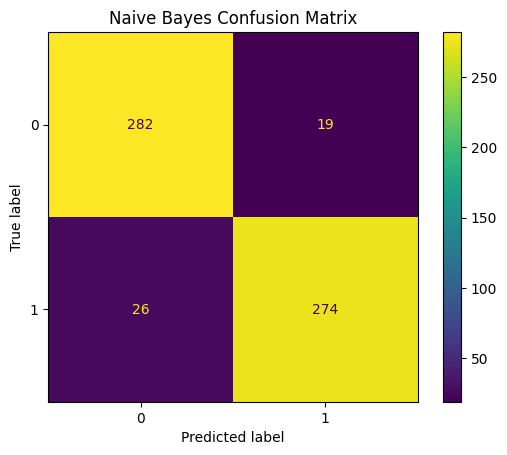

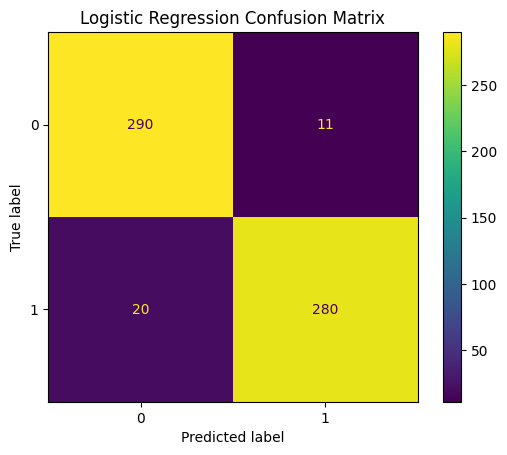

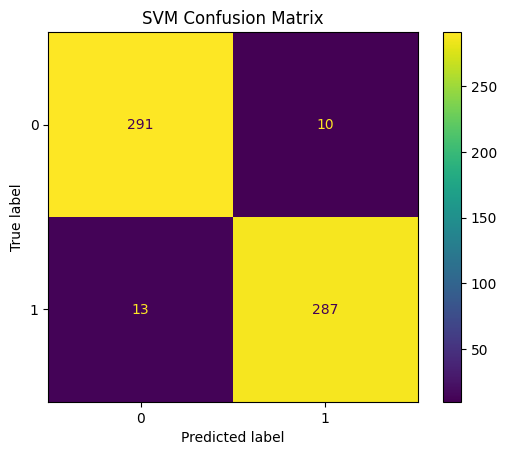

In [266]:
# ===============================
# 📊 ALL CONFUSION MATRICES
# ===============================

models = {
    "Naive Bayes": nb_pred,
    "Logistic Regression": lr_pred,
    "SVM": svm_pred
}

for name, pred in models.items():
    cm = confusion_matrix(y_test, pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    
    plt.title(f"{name} Confusion Matrix")
    plt.show()

In [267]:
print("\nNaive Bayes Report:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))
print("\nLogistic Regression Report:",accuracy_score(y_test,lr_pred))
print(classification_report(y_test, lr_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))


Naive Bayes Report: 0.9251247920133111
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       301
           1       0.94      0.91      0.92       300

    accuracy                           0.93       601
   macro avg       0.93      0.93      0.93       601
weighted avg       0.93      0.93      0.93       601


Logistic Regression Report: 0.9484193011647255
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       301
           1       0.96      0.93      0.95       300

    accuracy                           0.95       601
   macro avg       0.95      0.95      0.95       601
weighted avg       0.95      0.95      0.95       601

SVM Accuracy: 0.961730449251248
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       301
           1       0.97      0.96      0.96       300

    accuracy                           0.96       601
   macro

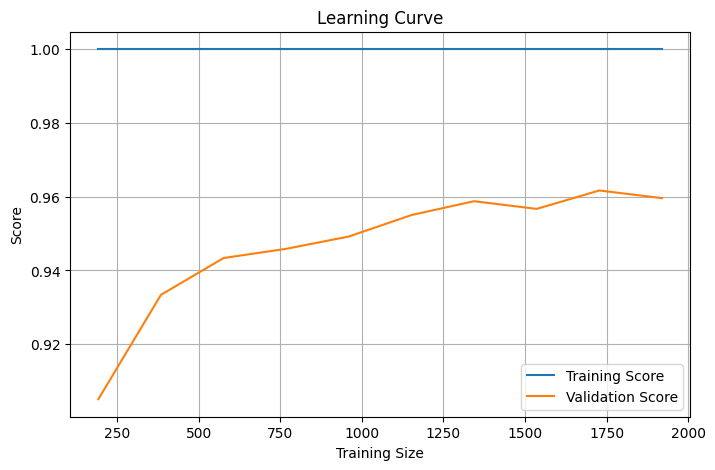

In [268]:


train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes_abs, train_scores, test_scores = learning_curve(
    best_svm,
    X_train_vec,
    y_train,
    train_sizes=train_sizes,
    cv=5,
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes_abs, train_mean, label="Training Score")
plt.plot(train_sizes_abs, test_mean, label="Validation Score")

plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Score")
plt.legend()

plt.grid()
plt.show()

In [269]:
# ===============================
# 📊 MODEL COMPARISON TABLE
# ===============================

model_names = ["Naive Bayes", "Logistic Regression", "SVM"]

accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, svm_pred)
]

comparison_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies
})

print(comparison_df)

                 Model  Accuracy
0          Naive Bayes  0.925125
1  Logistic Regression  0.948419
2                  SVM  0.961730


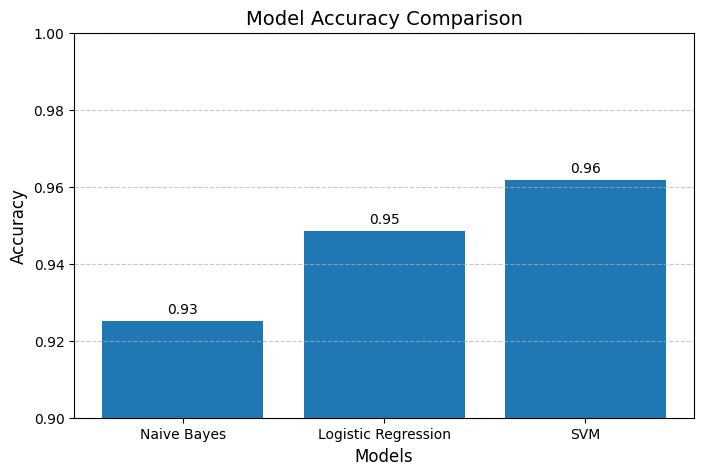

In [270]:
# ===============================
# 📈 PROFESSIONAL MODEL COMPARISON GRAPH
# ===============================

plt.figure(figsize=(8, 5))

bars = plt.bar(model_names, accuracies)

plt.title("Model Accuracy Comparison", fontsize=14)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

# Add value labels on top of bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f"{v:.2f}", ha='center', fontsize=10)

plt.ylim(0.9, 1.0)  # zoom into accuracy range for clarity

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

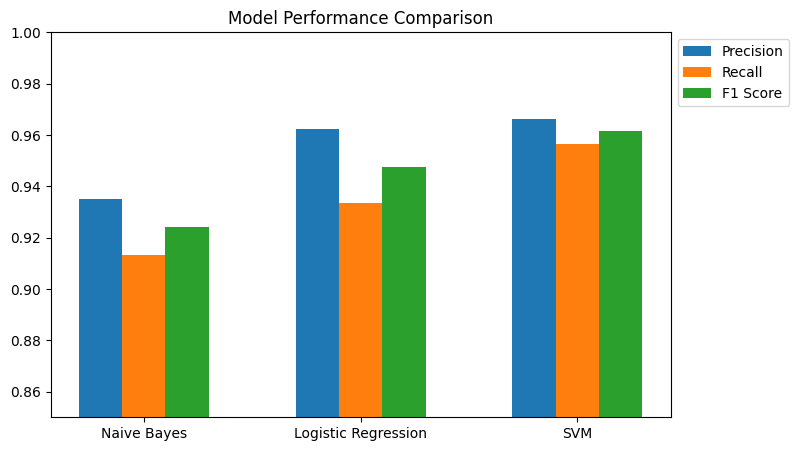

In [271]:
# ===============================
# 📊 PRECISION / RECALL / F1 GRAPH
# ===============================

from sklearn.metrics import precision_score, recall_score, f1_score

precision = [
    precision_score(y_test, nb_pred),
    precision_score(y_test, lr_pred),
    precision_score(y_test, svm_pred)
]

recall = [
    recall_score(y_test, nb_pred),
    recall_score(y_test, lr_pred),
    recall_score(y_test, svm_pred)
]

f1 = [
    f1_score(y_test, nb_pred),
    f1_score(y_test, lr_pred),
    f1_score(y_test, svm_pred)
]

x = np.arange(len(model_names))

plt.figure(figsize=(8,5))
plt.ylim(0.85, 1.0)

plt.bar(x - 0.2, precision, width=0.2, label="Precision")
plt.bar(x, recall, width=0.2, label="Recall")
plt.bar(x + 0.2, f1, width=0.2, label="F1 Score")

plt.xticks(x, model_names)
plt.title("Model Performance Comparison")
plt.legend(loc='upper left', bbox_to_anchor=(1,1))

plt.show()

In [272]:
best_model = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
print("Best Model:", best_model["Model"])
print("Best Accuracy:", best_model["Accuracy"])

Best Model: SVM
Best Accuracy: 0.961730449251248


In [273]:
scores = cross_val_score(best_svm, X_train_vec, y_train, cv=5)

print("SVM Cross Validation Accuracy:", scores.mean())

SVM Cross Validation Accuracy: 0.9595980595980595


In [274]:
# ===============================
# 🔍 RANDOM TEST FROM DATASET
# ===============================


def predict_news(text):
    processed = text
    
    # If you still want preprocessing:
    tokens = tokenize(text)
    tokens = clean_tokens(tokens)
    processed = " ".join(tokens)

    vec = vectorizer.transform([processed])

    pred = best_svm.predict(vec)

    return "REAL" if pred[0] == 1 else "FAKE"

In [275]:
def predict_with_confidence(text):
    tokens = tokenize(text)
    tokens = clean_tokens(tokens)
    processed = " ".join(tokens)

    vec = vectorizer.transform([processed])

    decision = best_svm.decision_function(vec)[0]
    prediction = best_svm.predict(vec)[0]

    return prediction, decision

In [276]:
for i in range(5):
    idx = random.randint(0, len(data)-1)

    text = data['processed_text'].iloc[idx]
    actual = data['label'].iloc[idx]

    prediction = predict_news(text)

    print("\n📝 TEXT:", text[:1000], "...")
    print("✅ ACTUAL:", "REAL" if actual == 1 else "FAKE")
    print("🤖 PREDICTED:", prediction)


📝 TEXT: ዋሽንግተን ፕሬዚዳንት ትራምፕ ስድራቤት ንምሕላው ዝግበር ወጻኢታት ንበጀት ሲክሬት ሰርቪስ Secret Service የጸብቦ ዋሽንግተን ሮይተርስ ኣመሪካ ሲክሬት ሰርቪስ US Secret Service ብሰንኪ ብመንግስቲ ዝተነብረ ደሞዝ ገደብ pay caps ድሕሪ ወርሒ መስከረም ንኣስታት ሰራሕተኛታቱ ትርፊ ሰዓት overtime ክፍሊት ክኸፍል ከምዘይክእል ዳይሬክተር ትካል ራንዶልፍ ቴክስ ኣለስ Randolph Tex Alles ሰኑይ ዕለት ገሊጹ ዳይሬክተር ኣለስ ባጀት ሕጽረት ምስቲ ንፕሬዚዳንት ዶናልድ ትራምፕን ስድራቤቶምን ንምሕላው ዝግበር ዘሎ ልዑል ወጻኢን ሓፈሻዊ ስራሕ ጽዕንቶ ምውሳኹን ኣተሓሒዙዎ ትካል ሕጂ ኣባላት ስድራቤት ትራምፕ ሓዊሱ ብጠቕላላ ንሪኮርድ ዝሰበረ ሰባት ምክልኻል ሓላፍነት ኣለዎ ግዜ ምምሕዳር ኦባማ ዝነበረ ሰባት ብጣዕሚ ዝበዝሀ ኣለስ ንጋዜጣ ዩኤስኤ ቱደይ USA Today ዝሃቦ ቃል ፕሬዚዳንት ዓቢ ስድራቤት ኣለዎ ንዓታቶም ምክልኻል ሓላፍነትና ብሕጊ ዝተወሰነ ኢሉ ዳይሬክተር ዓመታዊ ደሞዝን ትርፊ ሰዓትን ገደብ ንክውስኽ ንባይቶ ኣመሪካ Congress ሓቲቱ ዋይት ሃውስ ብወገኑ ምምሕዳር ትራምፕ ጸገም ንምፍታሕ ኮንግረስ ዝሰርሕ ኣፍሊጡ ...
✅ ACTUAL: REAL
🤖 PREDICTED: REAL

📝 TEXT: ዶናልድ ትራምፕ ፕረዚደንት ኦባማ ልዕሊ ትራምፕ ታወር Trump Tower ምስጢር ሰላላ መጥለፊ ቴሌፎን wiretap ኣዚዞም ክብል ዘቕረቦ ዘገርምን ብውዲት ዝመልኣን ጥርዓን ብዘይተፈለጠ መገዲ ባዕሉ ገበነኛ ምዃኑ ተኣሚኑ ክኸውን ይኽእል ትራምፕ ኣብቲ ብንግሆ ዝዘርገሖም ትዊታት ፕረዚደንት ኦባማ ወርሒ ጥቅምቲ October ጀሚሮም ንዕኡ ንምድኻም ልዕሊ ጎስጓስ ምርጫኡ ኒክሶናዊማካርቲዝማዊ NixonianMcCarthyesque ሃድን ጠንቆል

In [277]:
# ===============================
# ❌ SHOW WRONG PREDICTIONS
# ===============================

wrong = []

for i in range(len(X_test)):
    pred = best_svm.predict(X_test_vec[i])
    actual = y_test.iloc[i]

    if pred != actual:
        wrong.append(i)

print("Total wrong predictions:", len(wrong))

Total wrong predictions: 23


In [292]:
for i in wrong[:5]:
    print("\n📝 TEXT:", X_test.iloc[i][:1000])
    print("❌ ACTUAL:", y_test.iloc[i])
    print("🤖 PREDICTED:", best_svm.predict(X_test_vec[i])[0])


📝 TEXT: ዋሽንግተን ሮይተርስ ቸክ ተላኢኹ ድሕሪ ሓደ ኣቦ ዝተቐትለ ኣመሪካ ሰራዊት ሳርጀንት ፕረዚደንት ዶናልድ ትራምፕ ዝኣተዎ ልግስና ዝመልኦ ቃል ኣይተተግበረን ምባሉ ዋይት ሃውስ ረቡዕ ዝሃቦ መልሲ ክሪስ ባልድሪጅ ንጋዜጣ ዋሽንግተን ፖስት Washington Post ዝገለጾ ትራምፕ ብሰንኪ ሓደ ኣፍጋኒስታን ፖሊስ መኮነን ወርሒ ሰነ ንዝተቐትለ ወዲ ዓመት ወዱ ንስድራቤቱ ዶላር ክህቦም ቃል ኣትዩሎም ነይሩ እንተኾነ ገንዘብ ዘይበጽሀ ጋዜጣ ነጊርዋ ሓንቲ ወሃቢት ቃል ዋይት ሃውስ ረቡዕ ዝገለጸቶ መራኸቢ ብዙሃን ባልድሪጅ ዛንታ ብምስዓብ ኣቐዲምካ ዝተታሕዘ ጽልኢ biased agenda የቃልሑ ኣለዉ ኢላ ወሃቢ ቃል ዋይት ሃውስ ሊንድሰይ ዎልተር በኢመይል ዝሃበቶ መልሲ ቸክ ተላኢኹ ኢላ መራኸቢ ብዙሃን ብፕረዚደንት ብውልቂ ዝተገብረ ልግስናን ቅኑዕ ምንቅስቓስን ተጠቒሞም ጽልኢ ዘለዎ ኣጀንዳኦም ንምስጓም ምጥቃሞም ዘፈንፍን ክትብል ወሲኻ ጉዳይ ትራምፕ ንዝተቐትሉ ወተሃደራት ንዝወለዱ ስድራቤታት ዝሃቦ መልሲ ንዝተላዕለ ምስሕሓብ ተወሳኺ ኮይኑ ሶኑ ትራምፕ ገለ ካብቶም ቅድሚኡ ዝነበሩ ፕረዚደንታት ንዝተቐትሉ ወተሃደራት ስድራቤታት ንምጽንናዕ ዝኾነ ነገር ኣይገበሩን ምባሉ ሰፊሕ ነቐፌታ ኣስዒቡ ትራምፕ ንዝተዛረቦ ጭቡጥ መርትዖ ኣየቕረበን ዝበሎ ብኡንብኡ ሓሶት ምዃኑ ተረጋጊጹ ረቡዕ ትራምፕ ወኪል ፍሎሪዳ ፍረደሪካ ዊልሰን ዝሃበቶ ሓበሬታ ነጺግዎ ዊልሰን ትራምፕ ኒጀር ብጥይት ንዝተቐትለ ሳርጀንት ላ ዴቪድ ቲ ጆንሰን መበለት ወተሃደራት ንምንታይ ዝተመዝገበ ይፈልጥ ነይሩ ዝበላ ገሊጻ ነይራ ትራምፕ ረቡዕ ንጋዜጠኛታት እታ ወኪል ኮንግረስ ዝበለቶ ኣይበልኩን ኢሉ ምስቲ ሰበይቲ መበለት ኣዝዩ ጽቡቕ ዕላል ነይሩኒ ንሳ ግርምቲ ሰበይቲ እያ ትመስል ኢሉ ኣደ ሳርጀንት ጆንሰን ዝኾነት ኮዋ

In [279]:
scores = cross_val_score(best_svm, X_train_vec, y_train, cv=5)

print("Cross-validation scores:", scores)
print("Average:", scores.mean())

Cross-validation scores: [0.96465696 0.95833333 0.96458333 0.93958333 0.97083333]
Average: 0.9595980595980595


In [280]:
# ===============================
# 💾 SAVE MODEL
# ===============================
joblib.dump(best_svm, "../models/svm_model.pkl")
joblib.dump(vectorizer, "../models/vectorizer.pkl")
joblib.dump(stopwords, "../models/stopwords.pkl")

['../models/stopwords.pkl']